In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


(1) 資料轉換

In [2]:
%%writefile dataset_preprocessing.py
import xml.etree.ElementTree as ET
import numpy as np
import re

def load_dataset(xml_file):
    # 讀取 XML
    tree = ET.parse(xml_file)
    root = tree.getroot()
    ns = {"cwa": "urn:cwa:gov:tw:cwacommon:0.1"}
    content_text = root.find(".//cwa:Content", ns).text.strip()

    # 抓所有浮點數 (科學記號格式，例如 -999.0E+00)
    values = [float(v) for v in re.findall(r"[-+]?\d+\.\d+E[+-]\d+", content_text)]

    # 格點大小：120 × 67 = 8040
    data = np.array(values).reshape(120, 67)

    # 經緯度範圍
    lon = np.linspace(120.00, 121.98, 67)   # 東經
    lat = np.linspace(21.88, 25.45, 120)   # 北緯
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    # 展平成一維
    X = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])
    y = data.ravel()

    # (a) 分類資料集：label = 0 (無效值 -999), 1 (有效值)
    labels = (y != -999.0) * 1
    data_cla = np.column_stack([X, labels])

    # (b) 回歸資料集：只保留有效值
    mask = y != -999.0
    X_reg = X[mask]
    y_reg = y[mask]
    data_reg = np.column_stack([X_reg, y_reg])

    # ====== 檢查輸出 ======
    print("總資料筆數:", len(y))
    print("\n[分類資料集範例] (lon, lat, label)")
    print(data_cla[:5])
    print("\n[回歸資料集範例] (lon, lat, value)")
    print(data_reg[:5])
    print("\n分類資料集大小:", data_cla.shape)
    print("回歸資料集大小:", data_reg.shape)

    return data_cla, data_reg

# ✅ 呼叫測試
data_cla, data_reg = load_dataset("/content/drive/MyDrive/Colab Notebooks/O-A0038-003.xml")


Writing dataset_preprocessing.py


(2a) 分類模型

In [3]:
from dataset_preprocessing import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# ===== 讀取分類資料集 =====
data_cla, _ = load_dataset("/content/drive/MyDrive/Colab Notebooks/O-A0038-003.xml")

# 特徵與標籤
X = data_cla[:, :2].astype(float)   # (lon, lat)
y = data_cla[:, 2].astype(int)      # label (0 or 1)

# 標準化（對 Random Forest 不是必要，但加上也OK）
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 切分訓練/測試集 (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===== 建立 Random Forest 模型 =====
clf = RandomForestClassifier(
    n_estimators=200,    # 樹的數量
    max_depth=None,      # 不限制樹深
    random_state=42
)
clf.fit(X_train, y_train)

# ===== 評估模型 =====
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("✅ Random Forest 分類模型準確率:", acc)
print("\n分類報告:")
print(classification_report(y_test, y_pred, digits=3))


總資料筆數: 8040

[分類資料集範例] (lon, lat, label)
[[120.    21.88   0.  ]
 [120.03  21.88   0.  ]
 [120.06  21.88   0.  ]
 [120.09  21.88   0.  ]
 [120.12  21.88   0.  ]]

[回歸資料集範例] (lon, lat, value)
[[120.84  21.94  28.1 ]
 [120.72  21.97  28.6 ]
 [120.75  21.97  28.6 ]
 [120.78  21.97  27.8 ]
 [120.81  21.97  26.5 ]]

分類資料集大小: (8040, 3)
回歸資料集大小: (3495, 3)
總資料筆數: 8040

[分類資料集範例] (lon, lat, label)
[[120.    21.88   0.  ]
 [120.03  21.88   0.  ]
 [120.06  21.88   0.  ]
 [120.09  21.88   0.  ]
 [120.12  21.88   0.  ]]

[回歸資料集範例] (lon, lat, value)
[[120.84  21.94  28.1 ]
 [120.72  21.97  28.6 ]
 [120.75  21.97  28.6 ]
 [120.78  21.97  27.8 ]
 [120.81  21.97  26.5 ]]

分類資料集大小: (8040, 3)
回歸資料集大小: (3495, 3)
✅ Random Forest 分類模型準確率: 0.9819651741293532

分類報告:
              precision    recall  f1-score   support

           0      0.978     0.991     0.985       929
           1      0.988     0.969     0.978       679

    accuracy                          0.982      1608
   macro avg      0.983     0

(2b) 回歸模型

In [4]:
from dataset_preprocessing import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# ===== 讀取回歸資料集 =====
_, data_reg = load_dataset("/content/drive/MyDrive/Colab Notebooks/O-A0038-003.xml")

# 特徵與目標值
X = data_reg[:, :2].astype(float)   # (lon, lat)
y = data_reg[:, 2].astype(float)    # 溫度值 (°C)

# 標準化 (提升模型效果，尤其對於經緯度數值差異大時)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 切分訓練/測試集 (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===== 建立 Random Forest Regressor =====
reg = RandomForestRegressor(
    n_estimators=200,    # 樹的數量
    max_depth=None,      # 不限制樹深
    random_state=42
)
reg.fit(X_train, y_train)

# ===== 評估模型 =====
y_pred = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("✅ Random Forest 回歸模型")
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


總資料筆數: 8040

[分類資料集範例] (lon, lat, label)
[[120.    21.88   0.  ]
 [120.03  21.88   0.  ]
 [120.06  21.88   0.  ]
 [120.09  21.88   0.  ]
 [120.12  21.88   0.  ]]

[回歸資料集範例] (lon, lat, value)
[[120.84  21.94  28.1 ]
 [120.72  21.97  28.6 ]
 [120.75  21.97  28.6 ]
 [120.78  21.97  27.8 ]
 [120.81  21.97  26.5 ]]

分類資料集大小: (8040, 3)
回歸資料集大小: (3495, 3)
✅ Random Forest 回歸模型
MSE : 4.8137069242207176
RMSE: 2.1940161631630515
R²  : 0.8580994551680236


Samples: train=6432, test=1608
GDA accuracy (test): 0.5199
Confusion matrix (rows=true, cols=pred):
[[836  80]
 [692   0]]


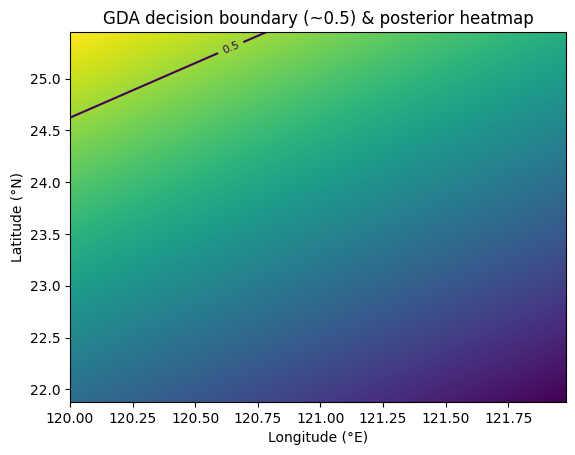

In [5]:
# ===================== Week 6 - Classification (GDA only; from scratch) =====================
# 依賴你的 dataset_preprocessing.py，不重複做資料轉換
# - 使用 (lon, lat, label) 進行 GDA（共用共變異數）
# - 印出 accuracy / confusion matrix
# - 畫 posterior 熱圖 + 0.5 決策邊界

import os, numpy as np
import matplotlib.pyplot as plt

# ---- 依你的 week4 路徑設定（請改為你實際使用的路徑）----
XML_PATH = "/content/drive/MyDrive/Colab Notebooks/O-A0038-003.xml"

# ---- 從你的模組讀資料：支援「import 時已產生 data_cla」或「呼叫函式取得」兩種 ----
try:
    import dataset_preprocessing as dp
    if hasattr(dp, "data_cla"):   # 你檔案末尾會直接呼叫 load_dataset(...)，這時 data_cla 已存在
        data_cla = dp.data_cla
    else:
        data_cla, _ = dp.load_dataset(XML_PATH)
except Exception as e:
    # 萬一上面失敗，嘗試只匯入函式
    from dataset_preprocessing import load_dataset
    data_cla, _ = load_dataset(XML_PATH)

# ---- 準備 (X, y) ----
data_cla = np.asarray(data_cla, dtype=float)   # 形狀: (8040, 3) -> [lon, lat, label]
X = data_cla[:, :2]
y = data_cla[:, 2].astype(int)

def train_test_split_np(X, y, test_ratio=0.2, seed=42):
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = np.arange(n); rng.shuffle(idx)
    t = int(n*test_ratio)
    te, tr = idx[:t], idx[t:]
    return X[tr], X[te], y[tr], y[te]

Xtr, Xte, ytr, yte = train_test_split_np(X, y, test_ratio=0.2, seed=42)

# ---- GDA（共用共變異數）----
class GDA:
    def fit(self, X, y):
        y = y.astype(int)
        N, d = X.shape
        self.phi_ = float(np.mean(y))            # P(y=1)
        X0 = X[y==0]; X1 = X[y==1]
        self.mu0_ = X0.mean(axis=0)
        self.mu1_ = X1.mean(axis=0)
        S0 = (X0 - self.mu0_).T @ (X0 - self.mu0_)
        S1 = (X1 - self.mu1_).T @ (X1 - self.mu1_)
        self.Sigma_ = (S0 + S1)/N + 1e-8*np.eye(d)  # pooled covariance + ridge
        # 預先計算
        self.invS_ = np.linalg.inv(self.Sigma_)
        _, self.logdet_ = np.linalg.slogdet(self.Sigma_)
        return self

    def _log_gauss(self, X, mean):
        d = X.shape[-1]
        diff = X - mean
        # -0.5 * ((x-μ)^T Σ^-1 (x-μ) + d log(2π) + log|Σ|)
        return -0.5*(np.sum(diff @ self.invS_ * diff, axis=-1) + X.shape[1]*np.log(2*np.pi) + self.logdet_)

    def predict_proba(self, X):
        logp0 = self._log_gauss(X, self.mu0_) + np.log(1 - self.phi_ + 1e-12)
        logp1 = self._log_gauss(X, self.mu1_) + np.log(self.phi_ + 1e-12)
        m = np.maximum(logp0, logp1)
        p0 = np.exp(logp0 - m); p1 = np.exp(logp1 - m)
        return p1/(p0+p1+1e-12)

    def predict(self, X, thr=0.5):
        return (self.predict_proba(X) >= thr).astype(int)

gda = GDA().fit(Xtr, ytr)
yhat = gda.predict(Xte)
acc = float(np.mean(yhat == yte))

# 混淆矩陣
cm = np.zeros((2,2), dtype=int)
for t, p in zip(yte, yhat):
    cm[t, p] += 1

print(f"Samples: train={len(ytr)}, test={len(yte)}")
print(f"GDA accuracy (test): {acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)

# ---- 決策邊界：posterior 熱圖 + 0.5 等高線 ----
lon_min, lon_max = X[:,0].min(), X[:,0].max()
lat_min, lat_max = X[:,1].min(), X[:,1].max()
lon_lin = np.linspace(lon_min, lon_max, 200)
lat_lin = np.linspace(lat_min, lat_max, 240)
LLONh, LLATh = np.meshgrid(lon_lin, lat_lin)
Xheat = np.c_[LLONh.ravel(), LLATh.ravel()]
P = gda.predict_proba(Xheat).reshape(LLONh.shape)

plt.figure()
plt.imshow(P, origin="lower",
           extent=[lon_min, lon_max, lat_min, lat_max],
           aspect="auto")
try:
    CS = plt.contour(LLONh, LLATh, P, levels=[0.5])
    plt.clabel(CS, inline=True, fontsize=8)
except Exception:
    pass
plt.title("GDA decision boundary (~0.5) & posterior heatmap")
plt.xlabel("Longitude (°E)"); plt.ylabel("Latitude (°N)")
plt.show()

# （可選）儲存圖檔：
# plt.savefig("/content/gda_boundary.png", dpi=150, bbox_inches="tight")


Model: QDA, φ=0.5; coords=km
Accuracy(test) = 0.8433
Confusion matrix (rows=true, cols=pred):
 [[744 172]
 [ 80 612]]


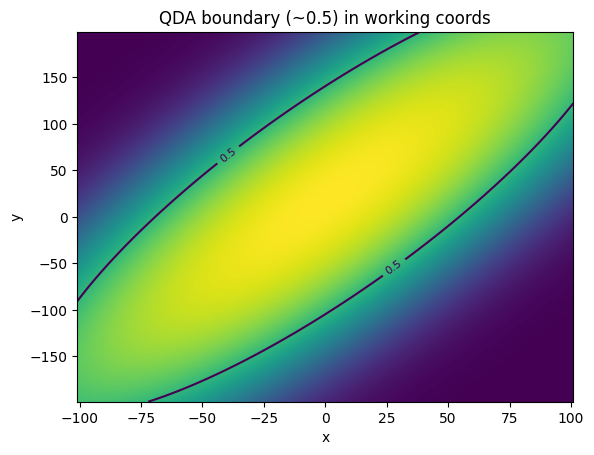

In [9]:
# ===================== QDA & 改良版決策邊界（可選功能開關） =====================
USE_QDA = True           # True=QDA(Σ0,Σ1)，False=GDA/LDA(共用Σ)
FORCE_PRIOR_HALF = True  # True=先驗 φ=0.5；False=用樣本比例
COORD_IN_KM = True       # True=把經緯度換成近似公里座標（較合理的尺度）

import numpy as np, matplotlib.pyplot as plt

def lonlat_to_km(Xlonlat):
    lon = Xlonlat[:,0]; lat = Xlonlat[:,1]
    lat0 = np.mean(lat) * np.pi/180.0
    k_lat = 111.32                    # 每度緯度約 111.32 km
    k_lon = 111.32 * np.cos(lat0)     # 每度經度 ≈ 111.32 * cos(lat)
    x = (lon - lon.mean()) * k_lon
    y = (lat - lat.mean()) * k_lat
    return np.c_[x, y]

# 選擇座標系
X_used = lonlat_to_km(X) if COORD_IN_KM else X

# 切分
def split(X, y, test_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y)); rng.shuffle(idx)
    t = int(len(y)*test_ratio)
    te, tr = idx[:t], idx[t:]
    return X[tr], X[te], y[tr], y[te]

Xtr, Xte, ytr, yte = split(X_used, y, test_ratio=0.2, seed=42)

# GDA/QDA 參數估計
def fit_gda_or_qda(X, y, shared_cov=True, force_prior=None):
    y = y.astype(int)
    N, d = X.shape
    phi = (np.mean(y) if force_prior is None else float(force_prior))
    X0 = X[y==0]; X1 = X[y==1]
    mu0 = X0.mean(axis=0); mu1 = X1.mean(axis=0)
    if shared_cov:
        S0 = (X0 - mu0).T @ (X0 - mu0)
        S1 = (X1 - mu1).T @ (X1 - mu1)
        Sigma = (S0 + S1)/N + 1e-8*np.eye(d)
        return {"phi":phi,"mu0":mu0,"mu1":mu1,"Sigma":Sigma,"shared":True}
    else:
        Sigma0 = np.cov((X0 - mu0).T, bias=True) + 1e-8*np.eye(d)
        Sigma1 = np.cov((X1 - mu1).T, bias=True) + 1e-8*np.eye(d)
        return {"phi":phi,"mu0":mu0,"mu1":mu1,"Sigma0":Sigma0,"Sigma1":Sigma1,"shared":False}

def logN(X, mean, invS, logdet):
    d = X.shape[-1]
    diff = X - mean
    return -0.5*(np.sum(diff @ invS * diff, axis=-1) + d*np.log(2*np.pi) + logdet)

def predict_proba(X, p):
    phi = p["phi"]
    if p["shared"]:
        invS = np.linalg.inv(p["Sigma"])
        _, logdet = np.linalg.slogdet(p["Sigma"])
        logp0 = logN(X, p["mu0"], invS, logdet) + np.log(1 - phi + 1e-12)
        logp1 = logN(X, p["mu1"], invS, logdet) + np.log(phi + 1e-12)
    else:
        invS0 = np.linalg.inv(p["Sigma0"]); _, logdet0 = np.linalg.slogdet(p["Sigma0"])
        invS1 = np.linalg.inv(p["Sigma1"]); _, logdet1 = np.linalg.slogdet(p["Sigma1"])
        logp0 = logN(X, p["mu0"], invS0, logdet0) + np.log(1 - phi + 1e-12)
        logp1 = logN(X, p["mu1"], invS1, logdet1) + np.log(phi + 1e-12)
    m = np.maximum(logp0, logp1)
    p0 = np.exp(logp0 - m); p1 = np.exp(logp1 - m)
    return p1/(p0+p1+1e-12)

def predict(X, p, thr=0.5):
    return (predict_proba(X, p) >= thr).astype(int)

# 訓練
params = fit_gda_or_qda(
    Xtr, ytr,
    shared_cov=(not USE_QDA),
    force_prior=(0.5 if FORCE_PRIOR_HALF else None),
)

yhat = predict(Xte, params)
acc = float(np.mean(yhat == yte))
cm = np.zeros((2,2), dtype=int)
for t, pr in zip(yte, yhat): cm[t, pr] += 1

print(f"Model: {'QDA' if USE_QDA else 'GDA/LDA'}, φ={'0.5' if FORCE_PRIOR_HALF else 'MLE'}; coords={'km' if COORD_IN_KM else 'lon/lat'}")
print(f"Accuracy(test) = {acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):\n", cm)

# 決策邊界（在使用中的座標系）
xs = np.linspace(X_used[:,0].min(), X_used[:,0].max(), 240)
ys = np.linspace(X_used[:,1].min(), X_used[:,1].max(), 260)
XX, YY = np.meshgrid(xs, ys)
P = predict_proba(np.c_[XX.ravel(), YY.ravel()], params).reshape(XX.shape)

plt.figure()
plt.imshow(P, origin="lower",
           extent=[xs.min(), xs.max(), ys.min(), ys.max()],
           aspect="auto")
try:
    CS = plt.contour(XX, YY, P, levels=[0.5])
    plt.clabel(CS, inline=True, fontsize=8)
except Exception:
    pass
plt.title(("QDA" if USE_QDA else "GDA") + " boundary (~0.5) in working coords")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


Classification accuracy (QDA, test): 0.8433
Confusion matrix (rows=true, cols=pred):
[[744 172]
 [ 80 612]]
Chosen alpha: 1e-02 (val RMSE=4.3872)
Regression RMSE (test): 4.3297 °C
Regression R^2  (test): 0.4316


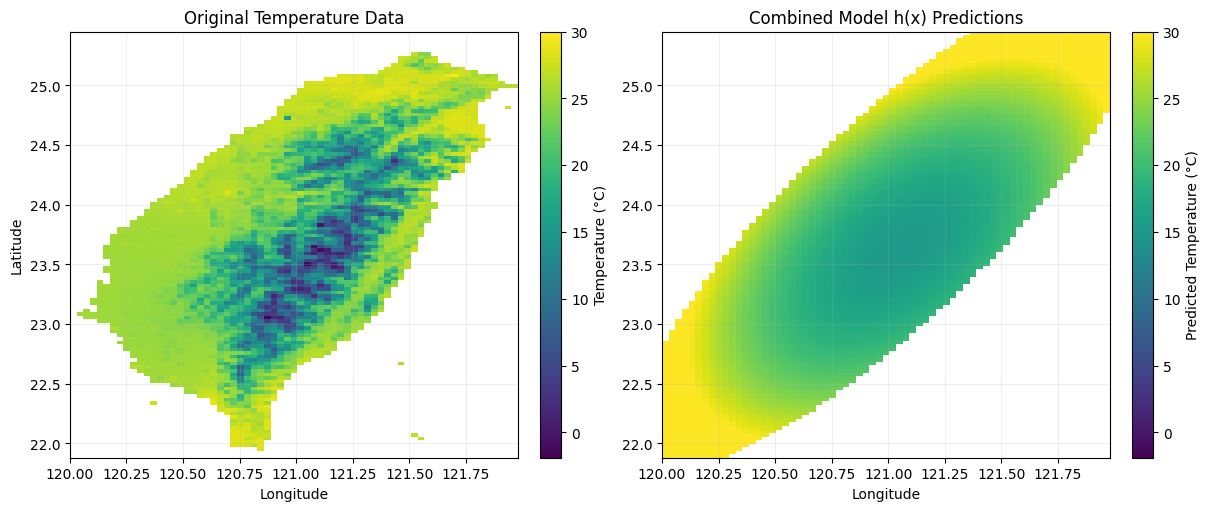

In [12]:
# ===================== Combined plots + metrics (with my suggested improvements) =====================
# 改動：
# 1) 回歸改用公里座標 (lon/lat -> km)
# 2) 在訓練集上做簡單 validation，自動挑選 Ridge alpha
# 3) 將回歸預測裁切到訓練值範圍；左右圖使用相同色階

import numpy as np
import matplotlib.pyplot as plt

# ---- 若你的 module 匯入時就已有 data_cla/data_reg，會直接取用；否則呼叫 load_dataset ----
XML_PATH = "/content/drive/MyDrive/Colab Notebooks/O-A0038-003.xml"  # ←換成你 week4 的路徑

try:
    import dataset_preprocessing as dp
    data_cla = getattr(dp, "data_cla", None)
    data_reg = getattr(dp, "data_reg", None)
    if data_cla is None or data_reg is None:
        data_cla, data_reg = dp.load_dataset(XML_PATH)
except Exception:
    from dataset_preprocessing import load_dataset
    data_cla, data_reg = load_dataset(XML_PATH)

data_cla = np.asarray(data_cla, dtype=float)  # (N_all, 3): [lon, lat, label]
data_reg = np.asarray(data_reg, dtype=float)  # (N_valid, 3): [lon, lat, value]

# ---------- Helpers ----------
def train_test_split_np(X, y, test_ratio=0.2, seed=42):
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = np.arange(n); rng.shuffle(idx)
    t = int(n*test_ratio)
    te, tr = idx[:t], idx[t:]
    return X[tr], X[te], y[tr], y[te]

def lonlat_to_km(X, ref_mean=None):
    """將 (lon,lat) 轉成近似公里座標；以 ref_mean 對齊中心避免不一致"""
    lon = X[:,0]; lat = X[:,1]
    if ref_mean is None:
        lon0, lat0 = lon.mean(), lat.mean()
    else:
        lon0, lat0 = ref_mean
    lat0_rad = np.deg2rad(lat0)
    k_lat = 111.32
    k_lon = 111.32 * np.cos(lat0_rad)
    x = (lon - lon0) * k_lon
    y = (lat - lat0) * k_lat
    return np.c_[x, y], (lon0, lat0)

# QDA（類別各自 Σ）；把 shared_cov=True 可切回 GDA/LDA
def fit_gda_or_qda(X, y, shared_cov=False, force_prior=0.5):
    y = y.astype(int)
    N, d = X.shape
    phi = float(np.mean(y) if force_prior is None else force_prior)
    X0, X1 = X[y==0], X[y==1]
    mu0, mu1 = X0.mean(axis=0), X1.mean(axis=0)
    if shared_cov:
        S0 = (X0 - mu0).T @ (X0 - mu0)
        S1 = (X1 - mu1).T @ (X1 - mu1)
        Sigma = (S0 + S1)/N + 1e-8*np.eye(d)
        return {"phi":phi,"mu0":mu0,"mu1":mu1,"Sigma":Sigma,"shared":True}
    else:
        Sigma0 = np.cov((X0 - mu0).T, bias=True) + 1e-8*np.eye(d)
        Sigma1 = np.cov((X1 - mu1).T, bias=True) + 1e-8*np.eye(d)
        return {"phi":phi,"mu0":mu0,"mu1":mu1,"Sigma0":Sigma0,"Sigma1":Sigma1,"shared":False}

def logN(X, mean, invS, logdet):
    d = X.shape[-1]
    diff = X - mean
    return -0.5*(np.sum(diff @ invS * diff, axis=-1) + d*np.log(2*np.pi) + logdet)

def post_proba(X, p):
    phi = p["phi"]
    if p["shared"]:
        invS = np.linalg.inv(p["Sigma"]); _, logdet = np.linalg.slogdet(p["Sigma"])
        logp0 = logN(X, p["mu0"], invS, logdet) + np.log(1 - phi + 1e-12)
        logp1 = logN(X, p["mu1"], invS, logdet) + np.log(phi + 1e-12)
    else:
        invS0 = np.linalg.inv(p["Sigma0"]); _, logdet0 = np.linalg.slogdet(p["Sigma0"])
        invS1 = np.linalg.inv(p["Sigma1"]); _, logdet1 = np.linalg.slogdet(p["Sigma1"])
        logp0 = logN(X, p["mu0"], invS0, logdet0) + np.log(1 - phi + 1e-12)
        logp1 = logN(X, p["mu1"], invS1, logdet1) + np.log(phi + 1e-12)
    m = np.maximum(logp0, logp1)
    p0, p1 = np.exp(logp0 - m), np.exp(logp1 - m)
    return p1/(p0+p1+1e-12)

def predict_cls(X, p, thr=0.5):
    return (post_proba(X, p) >= thr).astype(int)

class Poly2Ridge:
    def __init__(self, alpha=1e-6, center=True, include_bias=True):
        self.alpha = float(alpha); self.center = bool(center); self.include_bias = bool(include_bias)
        self.mean_ = None; self.w_ = None
    def _design(self, Xc):
        x, y = Xc[:,0], Xc[:,1]
        cols = []
        if self.include_bias: cols.append(np.ones_like(x))
        cols += [x, y, x*x, x*y, y*y]
        return np.stack(cols, axis=1)
    def fit(self, X, y):
        self.mean_ = X.mean(axis=0, keepdims=True) if self.center else np.zeros((1,X.shape[1]))
        Phi = self._design(X - self.mean_)
        A = Phi.T @ Phi + self.alpha*np.eye(Phi.shape[1])
        b = Phi.T @ y
        self.w_ = np.linalg.solve(A, b)
        return self
    def predict(self, X):
        Phi = self._design(X - self.mean_)
        return Phi @ self.w_

# ---------- 準備資料 ----------
X_cla = data_cla[:, :2]
y_cla = data_cla[:, 2].astype(int)

# 建立 (lon, lat)->value 的查表，以重建「原始溫度格」(含 -999)
def key_xy(a):
    return (round(a[0]/0.03)*0.03, round(a[1]/0.03)*0.03)

val_map = { key_xy(row[:2]): row[2] for row in data_reg }  # 只含有效點
orig_vals = []
for row in data_cla:
    k = key_xy(row[:2])
    orig_vals.append(val_map.get(k, -999.0))
orig_vals = np.array(orig_vals, dtype=float)

# 取得 lon/lat 的網格形狀（67×120）
lons = np.sort(np.unique(X_cla[:,0]))
lats = np.sort(np.unique(X_cla[:,1]))
ncol, nrow = len(lons), len(lats)
LLON, LLAT = np.meshgrid(lons, lats)  # shape (nrow, ncol)

# 重排成 (nrow, ncol) 的原始溫度場（-999 -> NaN）
Z_orig = np.full((nrow, ncol), np.nan)
for row, v in zip(data_cla, orig_vals):
    j = np.argmin(np.abs(lons - row[0]))
    i = np.argmin(np.abs(lats - row[1]))
    Z_orig[i, j] = np.nan if v <= -999 else v

# ---------- 訓練分類（QDA，φ=0.5） ----------
Xtr, Xte, ytr, yte = train_test_split_np(X_cla, y_cla, test_ratio=0.2, seed=42)
p = fit_gda_or_qda(Xtr, ytr, shared_cov=False, force_prior=0.5)
yhat = predict_cls(Xte, p)
acc = float(np.mean(yhat == yte))
cm = np.zeros((2,2), dtype=int)
for t, pr in zip(yte, yhat): cm[t, pr] += 1

print(f"Classification accuracy (QDA, test): {acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)

# ---------- 訓練回歸（Poly2 + Ridge；km 座標 + alpha 選擇 + 夾值） ----------
valid_mask = (orig_vals > -999)
X_reg_lonlat = X_cla[valid_mask]
y_reg = orig_vals[valid_mask]

# lon/lat -> km（用訓練資料的均值當 ref，之後預測也用同一個 ref 保持一致）
X_reg_km, ref_mean = lonlat_to_km(X_reg_lonlat)

# 切 test；再從 train 裡切 val 做 alpha 選擇
Xr_tr_all, Xr_te_km, yr_tr_all, yr_te = train_test_split_np(X_reg_km, y_reg, test_ratio=0.2, seed=42)
def split_train_val(X, y, val_ratio=0.2, seed=7):
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = np.arange(n); rng.shuffle(idx)
    t = int(n*val_ratio)
    val, tr = idx[:t], idx[t:]
    return X[tr], X[val], y[tr], y[val]

Xr_tr, Xr_val, yr_tr, yr_val = split_train_val(Xr_tr_all, yr_tr_all, val_ratio=0.2, seed=7)

alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
best_alpha, best_rmse = None, float("inf")
for a in alphas:
    m = Poly2Ridge(alpha=a, center=True).fit(Xr_tr, yr_tr)
    yv = m.predict(Xr_val)
    rmse_val = float(np.sqrt(np.mean((yv - yr_val)**2)))
    if rmse_val < best_rmse:
        best_rmse, best_alpha = rmse_val, a

# 用 train+val 重新訓練最好的 alpha
Xr_tv = np.vstack([Xr_tr, Xr_val])
yr_tv = np.concatenate([yr_tr, yr_val])
reg = Poly2Ridge(alpha=best_alpha, center=True).fit(Xr_tv, yr_tv)

# 測試集評估
yr_pred = reg.predict(Xr_te_km)
rmse = float(np.sqrt(np.mean((yr_pred - yr_te)**2)))
ss_res = float(np.sum((yr_te - yr_pred)**2))
ss_tot = float(np.sum((yr_te - np.mean(yr_te))**2))
r2 = float(1.0 - ss_res/max(ss_tot,1e-12))

print(f"Chosen alpha: {best_alpha:.0e} (val RMSE={best_rmse:.4f})")
print(f"Regression RMSE (test): {rmse:.4f} °C")
print(f"Regression R^2  (test): {r2:.4f}")

# ---------- 組合模型 h(x) ----------
# 在完整網格上做預測：C(x)==1 用回歸，否則 NaN（視覺上等於遮蔽）
X_grid_lonlat = np.c_[LLON.ravel(), LLAT.ravel()]
C_grid = predict_cls(X_grid_lonlat, p).reshape(LLON.shape)

# 網格也要用相同 ref 做 km 轉換
X_grid_km, _ = lonlat_to_km(X_grid_lonlat, ref_mean=ref_mean)
R_grid = reg.predict(X_grid_km).reshape(LLON.shape)

# 依訓練值範圍做 clip，避免 overshoot；兩張圖共用同一色階
y_min, y_max = y_reg.min(), y_reg.max()
R_grid = np.clip(R_grid, y_min, y_max)
H_grid = np.where(C_grid==1, R_grid, np.nan)

# ---------- 繪圖：左右並排（相同色階便於比較） ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axes[0].imshow(
    np.clip(Z_orig, y_min, y_max), origin="lower",
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    aspect="auto", vmin=y_min, vmax=y_max
)
axes[0].set_title("Original Temperature Data")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
cb0 = plt.colorbar(im0, ax=axes[0]); cb0.set_label("Temperature (°C)")
axes[0].grid(alpha=0.2)

im1 = axes[1].imshow(
    H_grid, origin="lower",
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    aspect="auto", vmin=y_min, vmax=y_max
)
axes[1].set_title("Combined Model h(x) Predictions")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("")
cb1 = plt.colorbar(im1, ax=axes[1]); cb1.set_label("Predicted Temperature (°C)")
axes[1].grid(alpha=0.2)

plt.show()
